<a href="https://colab.research.google.com/github/MadisonJBollinger/lis5693/blob/main/Lab-7/lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lab-7: Sentiment Analysis (using the dataset from Lab 4).

In [29]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
import requests
import io

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [30]:
url= "https://raw.githubusercontent.com/MadisonJBollinger/lis5693/refs/heads/main/lab-4/bbc-news-data.csv"
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors
text = response.text
df = pd.read_csv(io.StringIO(text), sep='\t')
print(df.head())

   category filename                              title  \
0  business  001.txt  Ad sales boost Time Warner profit   
1  business  002.txt   Dollar gains on Greenspan speech   
2  business  003.txt  Yukos unit buyer faces loan claim   
3  business  004.txt  High fuel prices hit BA's profits   
4  business  005.txt  Pernod takeover talk lifts Domecq   

                                             content  
0   Quarterly profits at US media giant TimeWarne...  
1   The dollar has hit its highest level against ...  
2   The owners of embattled Russian oil giant Yuk...  
3   British Airways has blamed high fuel prices f...  
4   Shares in UK drinks and food firm Allied Dome...  


This is the data used from previous lab and the coding is pulled directly from it to ensure that data is properly retrieved.

In [31]:
df_subset = df[['title', 'content']].copy()

In [32]:
df_subset['content'] = df_subset['content'].str.replace("[^a-zA-Z#]", "   ")
df_subset['content'] = df_subset['content'].str.casefold()
print(df_subset.head(10))

                               title  \
0  Ad sales boost Time Warner profit   
1   Dollar gains on Greenspan speech   
2  Yukos unit buyer faces loan claim   
3  High fuel prices hit BA's profits   
4  Pernod takeover talk lifts Domecq   
5   Japan narrowly escapes recession   
6   Jobs growth still slow in the US   
7   India calls for fair trade rules   
8  Ethiopia's crop production up 24%   
9  Court rejects $280bn tobacco case   

                                             content  
0   quarterly profits at us media giant timewarne...  
1   the dollar has hit its highest level against ...  
2   the owners of embattled russian oil giant yuk...  
3   british airways has blamed high fuel prices f...  
4   shares in uk drinks and food firm allied dome...  
5   japan's economy teetered on the brink of a te...  
6   the us created fewer jobs than expected in ja...  
7   india, which attends the g7 meeting of seven ...  
8   ethiopia produced 14.27 million tonnes of cro...  
9   a us 

Based on the information provided in the df.head print, I have chosen the title and the content to use for my test

In [33]:
df1 = pd.DataFrame()
df1['title'] = ['9999999999999']
df1['sentiment_type'] = 'NA99NA'
df1['sentiment_score'] = 0

In [34]:
print('Processing sentiment analysis...')
sid = SentimentIntensityAnalyzer()

all_scores_list = [] # Use a list to collect results

for index, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['content']) # Access by column name for clarity and robustness
    for key, value in scores.items():
        all_scores_list.append({
            'title': row['title'], # Access by column name
            'sentiment_type': key,
            'sentiment_score': value
        })

# Create a DataFrame from the list of dictionaries after the loop
t_df_all_types = pd.DataFrame(all_scores_list)

# Filter for compound sentiment and remove duplicates
t_df_cleaned = t_df_all_types[t_df_all_types.sentiment_type == 'compound'].drop_duplicates()

print(t_df_cleaned.head(10))

Processing sentiment analysis...
                                title sentiment_type  sentiment_score
3   Ad sales boost Time Warner profit       compound           0.9950
7    Dollar gains on Greenspan speech       compound           0.9347
11  Yukos unit buyer faces loan claim       compound          -0.8860
15  High fuel prices hit BA's profits       compound           0.9790
19  Pernod takeover talk lifts Domecq       compound           0.6652
23   Japan narrowly escapes recession       compound           0.6204
27   Jobs growth still slow in the US       compound           0.9547
31   India calls for fair trade rules       compound          -0.6795
35  Ethiopia's crop production up 24%       compound          -0.2023
39  Court rejects $280bn tobacco case       compound           0.2263


For my text, I have chosen to do content. This is because it has the most data to work off of for a run to gain a sentiment score.

In [35]:
df_output = pd.merge(df, t_df_cleaned, on='title', how='inner')
print(df_output.head(10))

   category filename                              title  \
0  business  001.txt  Ad sales boost Time Warner profit   
1  business  002.txt   Dollar gains on Greenspan speech   
2  business  003.txt  Yukos unit buyer faces loan claim   
3  business  004.txt  High fuel prices hit BA's profits   
4  business  005.txt  Pernod takeover talk lifts Domecq   
5  business  006.txt   Japan narrowly escapes recession   
6  business  007.txt   Jobs growth still slow in the US   
7  business  008.txt   India calls for fair trade rules   
8  business  009.txt  Ethiopia's crop production up 24%   
9  business  010.txt  Court rejects $280bn tobacco case   

                                             content sentiment_type  \
0   Quarterly profits at US media giant TimeWarne...       compound   
1   The dollar has hit its highest level against ...       compound   
2   The owners of embattled Russian oil giant Yuk...       compound   
3   British Airways has blamed high fuel prices f...       compoun

To merge, I chose the title, which is a decent column, though it could lead to some misinterpretation if there is any duplications in the dataset, though as it is based on one news source, it is less likely to have as high a possibility when using multiple news sources.

In [36]:
df_output[["sentiment_score"]].describe()

,sentiment_score
count,2253.000000
mean,0.403809
std,0.788960
min,-0.999900
25%,-0.393200
50%,0.920000
75%,0.983200
max,1.000000


The describe command showed that the dataset gave us a great range of polarity if it was done accurately. The minimum score was -0.999900 and a maximum of 1.000000. The dataset was mostly positive with the mean of 0.43809 and half of the data is at least 0.92000.

<Axes: title={'center': 'Sentiment Score'}, xlabel='filename', ylabel='Mean Sentiment Score'>

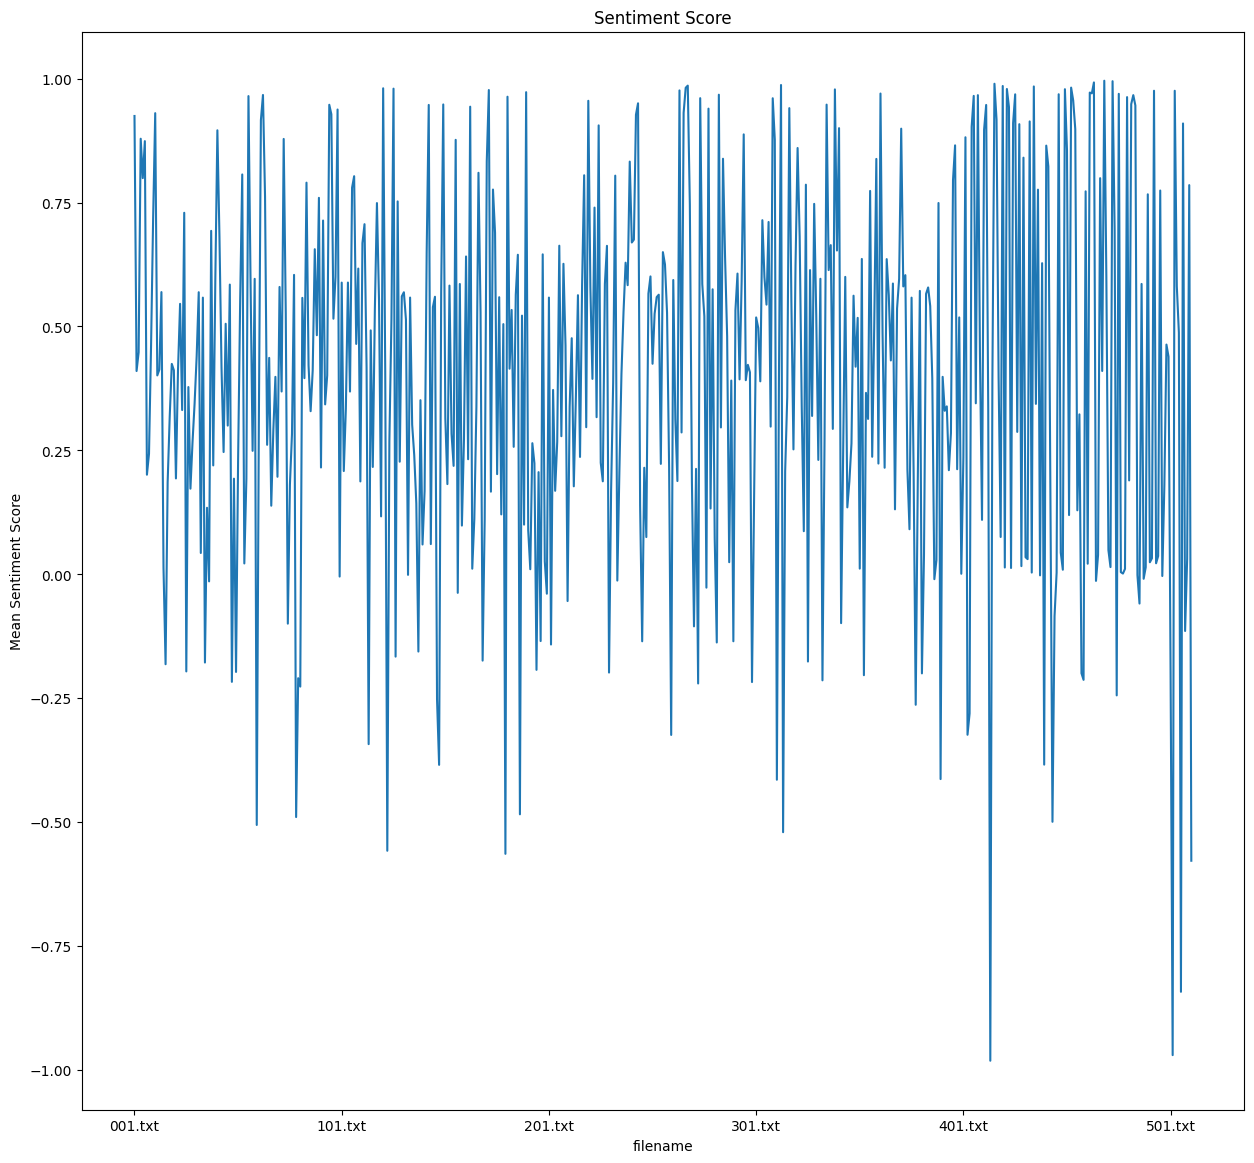

In [37]:
#generate mean of sentiment_score by period
dfg = df_output.groupby(['filename'])['sentiment_score'].mean()
dfg.index = dfg.index.astype(str).str.replace(r'\.0$', '', regex=True)
#create a bar plot
dfg.plot(kind='line', title='Sentiment Score', ylabel='Mean Sentiment Score',
         xlabel='filename', figsize=(15, 14))

I chose filename as the e-axis as that is the only numeric column in my dataset that can be used. Increasing the figure size allows me to better read the graph output.

<Axes: title={'center': 'sentiment_score'}, xlabel='category', ylabel='Mean Sentiment Score'>

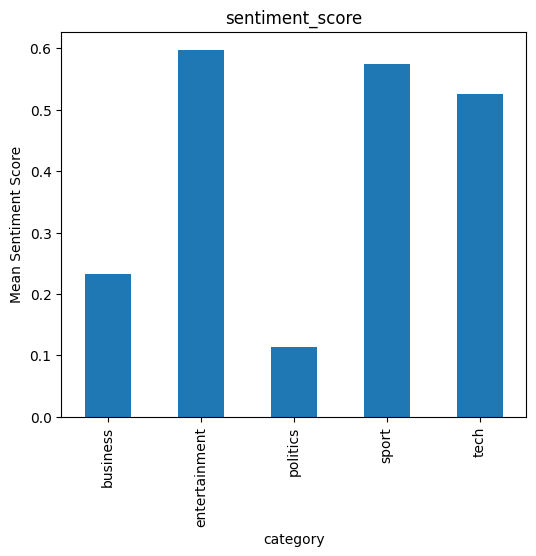

In [38]:
dfg = df_output.groupby(['category'])['sentiment_score'].mean()
dfg.plot(kind='bar', title='sentiment_score', ylabel='Mean Sentiment Score',
         xlabel='category', figsize=(6, 5))

The category graph shows that the sentiment scores of politics and business are not as favorably looked upon as that of tech sport and entertainment, all three of which have fairly high scores compared to the former two, most of which are 2.5 to 3 times the mean score.

([0, 1, 2, 3, 4],
 [Text(0, 0, 'business'),
  Text(1, 0, 'entertainment'),
  Text(2, 0, 'politics'),
  Text(3, 0, 'sport'),
  Text(4, 0, 'tech')])

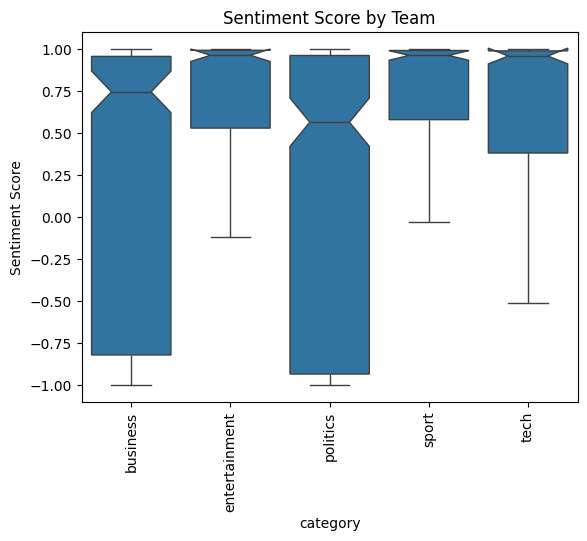

In [39]:
import seaborn as sns
#create seaborn boxplots by group
sns.boxplot(x='category', y='sentiment_score', notch = True,
            data=df_output, showfliers=False).set(title='Sentiment Score by Team')
#modify axis labels
plt.xlabel('category')
plt.ylabel('Sentiment Score')
plt.xticks(rotation=90)


In [42]:
!pip install "vl-convert-python>=1.6.0"
import altair as alt

# Prepare data for mean sentiment score by filename
dfg_filename = df_output.groupby('filename')['sentiment_score'].mean().reset_index()
dfg_filename['filename'] = dfg_filename['filename'].astype(str).str.replace(r'\.0$', '', regex=True)

# Create the Altair bar chart for Sentiment Score by category
chart_filename = alt.Chart(dfg_filename).mark_bar().encode(
    x=alt.X('filename:N', title='filename'), # Use :N for nominal (categorical) data
    y=alt.Y('sentiment_score:Q', title='Mean Sentiment Score'),
    color=alt.Color('filename:N', legend=alt.Legend(title="filename")),
    tooltip=['filename', 'sentiment_score']
).properties(
    title='Mean Sentiment Score by filename'
).interactive()

chart_filename

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 45.4 MB/s eta 0:00:00


alt.Chart(...)

The Altair bar chart is a great way to find where each file falls on the line better than the line graph previously ran. I can find the negatives faster using this graph than with the line.

In [43]:
import altair as alt

# Prepare data for mean sentiment score by category
dfg_category = df_output.groupby('category')['sentiment_score'].mean().reset_index()

# Create the Altair bar chart for Sentiment Score by category
chart_category = alt.Chart(dfg_category).mark_bar().encode(
    x=alt.X('category:N', title='category', sort='-y'), # Sort by sentiment score
    y=alt.Y('sentiment_score:Q', title='Mean Sentiment Score'),
    color=alt.Color('category:N', legend=alt.Legend(title="category")),
    tooltip=['category', 'sentiment_score']
).properties(
    title='Mean Sentiment Score by category'
).interactive()

chart_category

alt.Chart(...)

Overall, this was a great assignment that I enjoyed and found a lot more use in than I though I would based on the readings for this module. Having it in action provided more insight, though the information is only a simple example and this type of analysis would be much more in depth with a dataset that had more columns to determine sentiment on.
There was a couple of issues with needing to upgrade the installments to get the code to run properly.